<a href="https://colab.research.google.com/github/Jbaner/Module-3-Assignments/blob/main/Milestone_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Milestone One: Form Your Team, Understand the Problem, and Explore the Data

#### **Due:** July 12th @ 11:59 PM (with a 2 hour & 1 minute grace period)

#### **Important:** There is **no late period** for this assignment, as manual grading must begin immediately after the deadline.

## What You Will Do in This Milestone

1. Form your project team and complete the **Team Contract** (available in the Homework Repository). Submit one copy to Gradescope.
2. Select a **team leader**, who will submit this notebook on behalf of the team after everyone has contributed to the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>Gradescope guide</a> explains how to add group members to a submission.
3. After completing this milestone, **each team member** must complete an **Individual Team Evaluation** (available in the Homework Repository) and submit it individually to Gradescope.
4. Complete a simplified version of the **Machine Learning Project Checklist** from Appendix A of *Hands-On Machine Learning* (p. 779):

> **Part 1:** Frame the problem and understand the project goals   
> **Part 2:** Explore and understand the dataset   
> **Part 3:** Clean and prepare the data   
> **Part 4:** Investigate feature relationships   
> **Part 5:** Develop hypotheses for feature engineering and preprocessing

## The Dataset

All teams will work with the same dataset: a reduced version of the Zillow housing dataset used in the **Zillow Prize** competition on Kaggle in 2017 (unfortunately, the competition has long since ended!).

Your goal is to predict a property's **assessed tax value** (`taxvaluedollarcnt`) from a large collection of property characteristics. The dataset contains many of the challenges encountered in real machine learning projects, including:

* Missing values
* Potential outliers
* Redundant and highly correlated features
* Identifier variables that may not be useful for prediction
* Features that require careful interpretation before preprocessing

Unlike many educational datasets, this one has **not** been extensively preprocessed. Throughout this milestone, your objective is to understand the data, identify potential issues, and develop hypotheses about preprocessing and feature engineering. In **Milestone 2**, you will evaluate many of these ideas experimentally to determine whether they actually improve model performance.



In [2]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.**

For a detailed description of the dataset features, please refer to  **Appendix 1** below.


In [3]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercising all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data;
- Develop a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:**

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

> The objective of this project is to buid a machine learnig model that predicts a property's assesed tax value ('taxvaluedollarcnt') based on its phusical features, geographic locations, year built and other relevant property attributes.

>From a business standpoint, accurate property value predictions provide valuale insights for stakeholders such as real estate agencies, property investors, financial institutions and tax assesment authorities. These predictions can support property valuation, investment decision-making, pricing strategies, portfolio management, and market analysis. By automating the valuation process with data-driven models, organizations can improve efficiency, reduce the reliance on manual appraisals, and make more consistent and informed decisions at scale.


**1.2:**  How will your solution be used?

> The predictive model will be used to estimate properties values more accurately and consistently. In practice, this supports fair tax assessments (based on their characteristics, such as size, location, age, and amenities), improved financial forecasting, and reduces the need for manual property appraisals. The solution provides data-driven insights that help organizations identify mispriced homes, detect anomalies and make better planning and bidgeting decisions. By automatic valuation and improving accuracy, the model enhances operational efficiency and supports strategic decision-making across departments.

**1.3:**  How should success (or failure) be measured?

> Success should be measured by how accurately the model predicts a property's assessed tax value on unseen data.Since this is a regression problem, it will be measured by how accurately the model predicts a property's assessed tax value on unseen data using metrics such as RMSE, MAE, R², and cross-validation performance. From a business perspective, success means that the model provides property value estimates that are accurate enough to support decision-making. Accurate predictions can help tax assessors perform fair assessments, enable real estate professionals and investors to identify appropriately valued or potentially undervalued properties, and reduce the time and cost associated with manual appraisals. The model should also produce consistent predictions across different types of properties and geographic regions. Failure would be indicated by large prediction errors, low explanatory power, or unstable performance across validation and test datasets. From a business standpoint, poor predictions could lead to inaccurate property assessments, poor investment decisions, mispricing of properties, and reduced trust in the model, ultimately limiting its usefulness as a decision-support tool.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Feature Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process.
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [4]:
#1. data loading:
print("Number of rows and columns")
print(df.shape)
df.head()

#2. Description:
print("\nDataset Information:")
df.info()
#print("\nStatistical Analysis:")
#display(df.describe())

#Summary
summary = pd.DataFrame({"Feature Name": df.columns,
                        "Data Type": df.dtypes.values,
                        "Missing Values(%)": (df.isnull().mean()*100).round(1).values,
                       "Unique Values": df.nunique().values})
print("\nDataset Summary:")
print(summary)

#Target
print("-------------------------------------------------------------")
print("\nTarget summary")
# Summary statistics
display(df['taxvaluedollarcnt'].describe())
# Missing values in target
print("Missing Values: ", (df['taxvaluedollarcnt'].isnull().mean() * 100).round(1))
# Number of unique target values
print("Unique Values: ", df['taxvaluedollarcnt'].nunique())

Number of rows and columns
(77613, 55)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12 

,taxvaluedollarcnt
count,7.757800e+04
mean,4.901506e+05
std,6.537979e+05
min,1.000000e+03
25%,2.068985e+05
50%,3.588785e+05
75%,5.690000e+05
max,4.906124e+07


Missing Values:  0.0
Unique Values:  50949


In [6]:
high_missing = summary[summary['Missing Values(%)'] > 94]

print(high_missing[['Feature Name']])

                Feature Name
2   architecturalstyletypeid
3               basementsqft
6        buildingclasstypeid
9                 decktypeid
13      finishedsquarefeet13
14      finishedsquarefeet15
16       finishedsquarefeet6
22            hashottuborspa
28               poolsizesum
29              pooltypeid10
30               pooltypeid2
41               storytypeid
43    typeconstructiontypeid
45        yardbuildingsqft17
46        yardbuildingsqft26
49             fireplaceflag
51        taxdelinquencyflag
52        taxdelinquencyyear


#### **2.A Discussion:**

Answer the following questions. You may wish to examine Appendix 3 before starting.

**2.A.1:**  Which features are categorical?

> **(IDs, Flags, Codes)** parcelid, airconditioningtypeid,    architecturalstyletypeid, buildingclasstypeid, buildingqualitytypeid, decktypeid, fips, hashottuborspa, heatingorsystemtypeid, poolcnt, pooltypeid10, pooltypeid2, pooltypeid7, propertycountylandusecode, propertylandusetypeid, propertyzoningdesc, regionidcity, regionidcounty, regionidneighborhood, regionidzip, storytypeid, typeconstructiontypeid, fireplaceflag, taxdelinquencyflag, assessmentyear, taxdelinquencyyear, unitcnt, numberofstories

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

>Based on the purpose of predicting "**taxvaluedollarcnt**", several features cab be removed because they are unlikely to improve model performance. "**parcelid**" is a unique identifier, it does not describe any property feature and it has no predictive values. Features with very high missing values such as **("buildingclasstypeid", "storytypeid", "architecturalstyletypeid", "typeconstructiontypeid", "basementsqft", "finishedsquarefeet13", "yardbuildingsqft26", "pooltypeid10", "finishedsquarefeet6", "decktypeid", "finishedsquarefeet15","hashottuborspa", "poolsizesum", "pooltypeid2", "yardbuildingsqft17", "fireplaceflag", "taxdelinquencyflag", "taxdelinquencyyear")** contain too little information to add meaningful insights and it might introduce noise in the prediction. Redundant variables such as (**bathroomcnt** and **calculatedbathnbr** or **fireplacecnt** and **fireplaceflag**) may capture similar information which can introduce multicollinearity, only the most informative features can be kept after further review to simplify the model.


**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

> Features such as "buildingclasstypeid", "storytypeid", "architecturalstyletypeid", "typeconstructiontypeid", "basementsqft", "finishedsquarefeet13", "yardbuildingsqft26", "pooltypeid10", "finishedsquarefeet6", "decktypeid", "finishedsquarefeet15","hashottuborspa", "poolsizesum", "pooltypeid2", "yardbuildingsqft17", "fireplaceflag", "taxdelinquencyflag", "taxdelinquencyyear"
 contain over 95% missing values and these variables will not contribute any meaningful predictive information in the model.



**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

>"**Parcelid**" appears to be useless because it has nearly one unique value per observation, making it an unique identifier rather than a predictive variable.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization
- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the target and three (3) additional features that you believe are particularly informative or interesting (a total of four features):
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

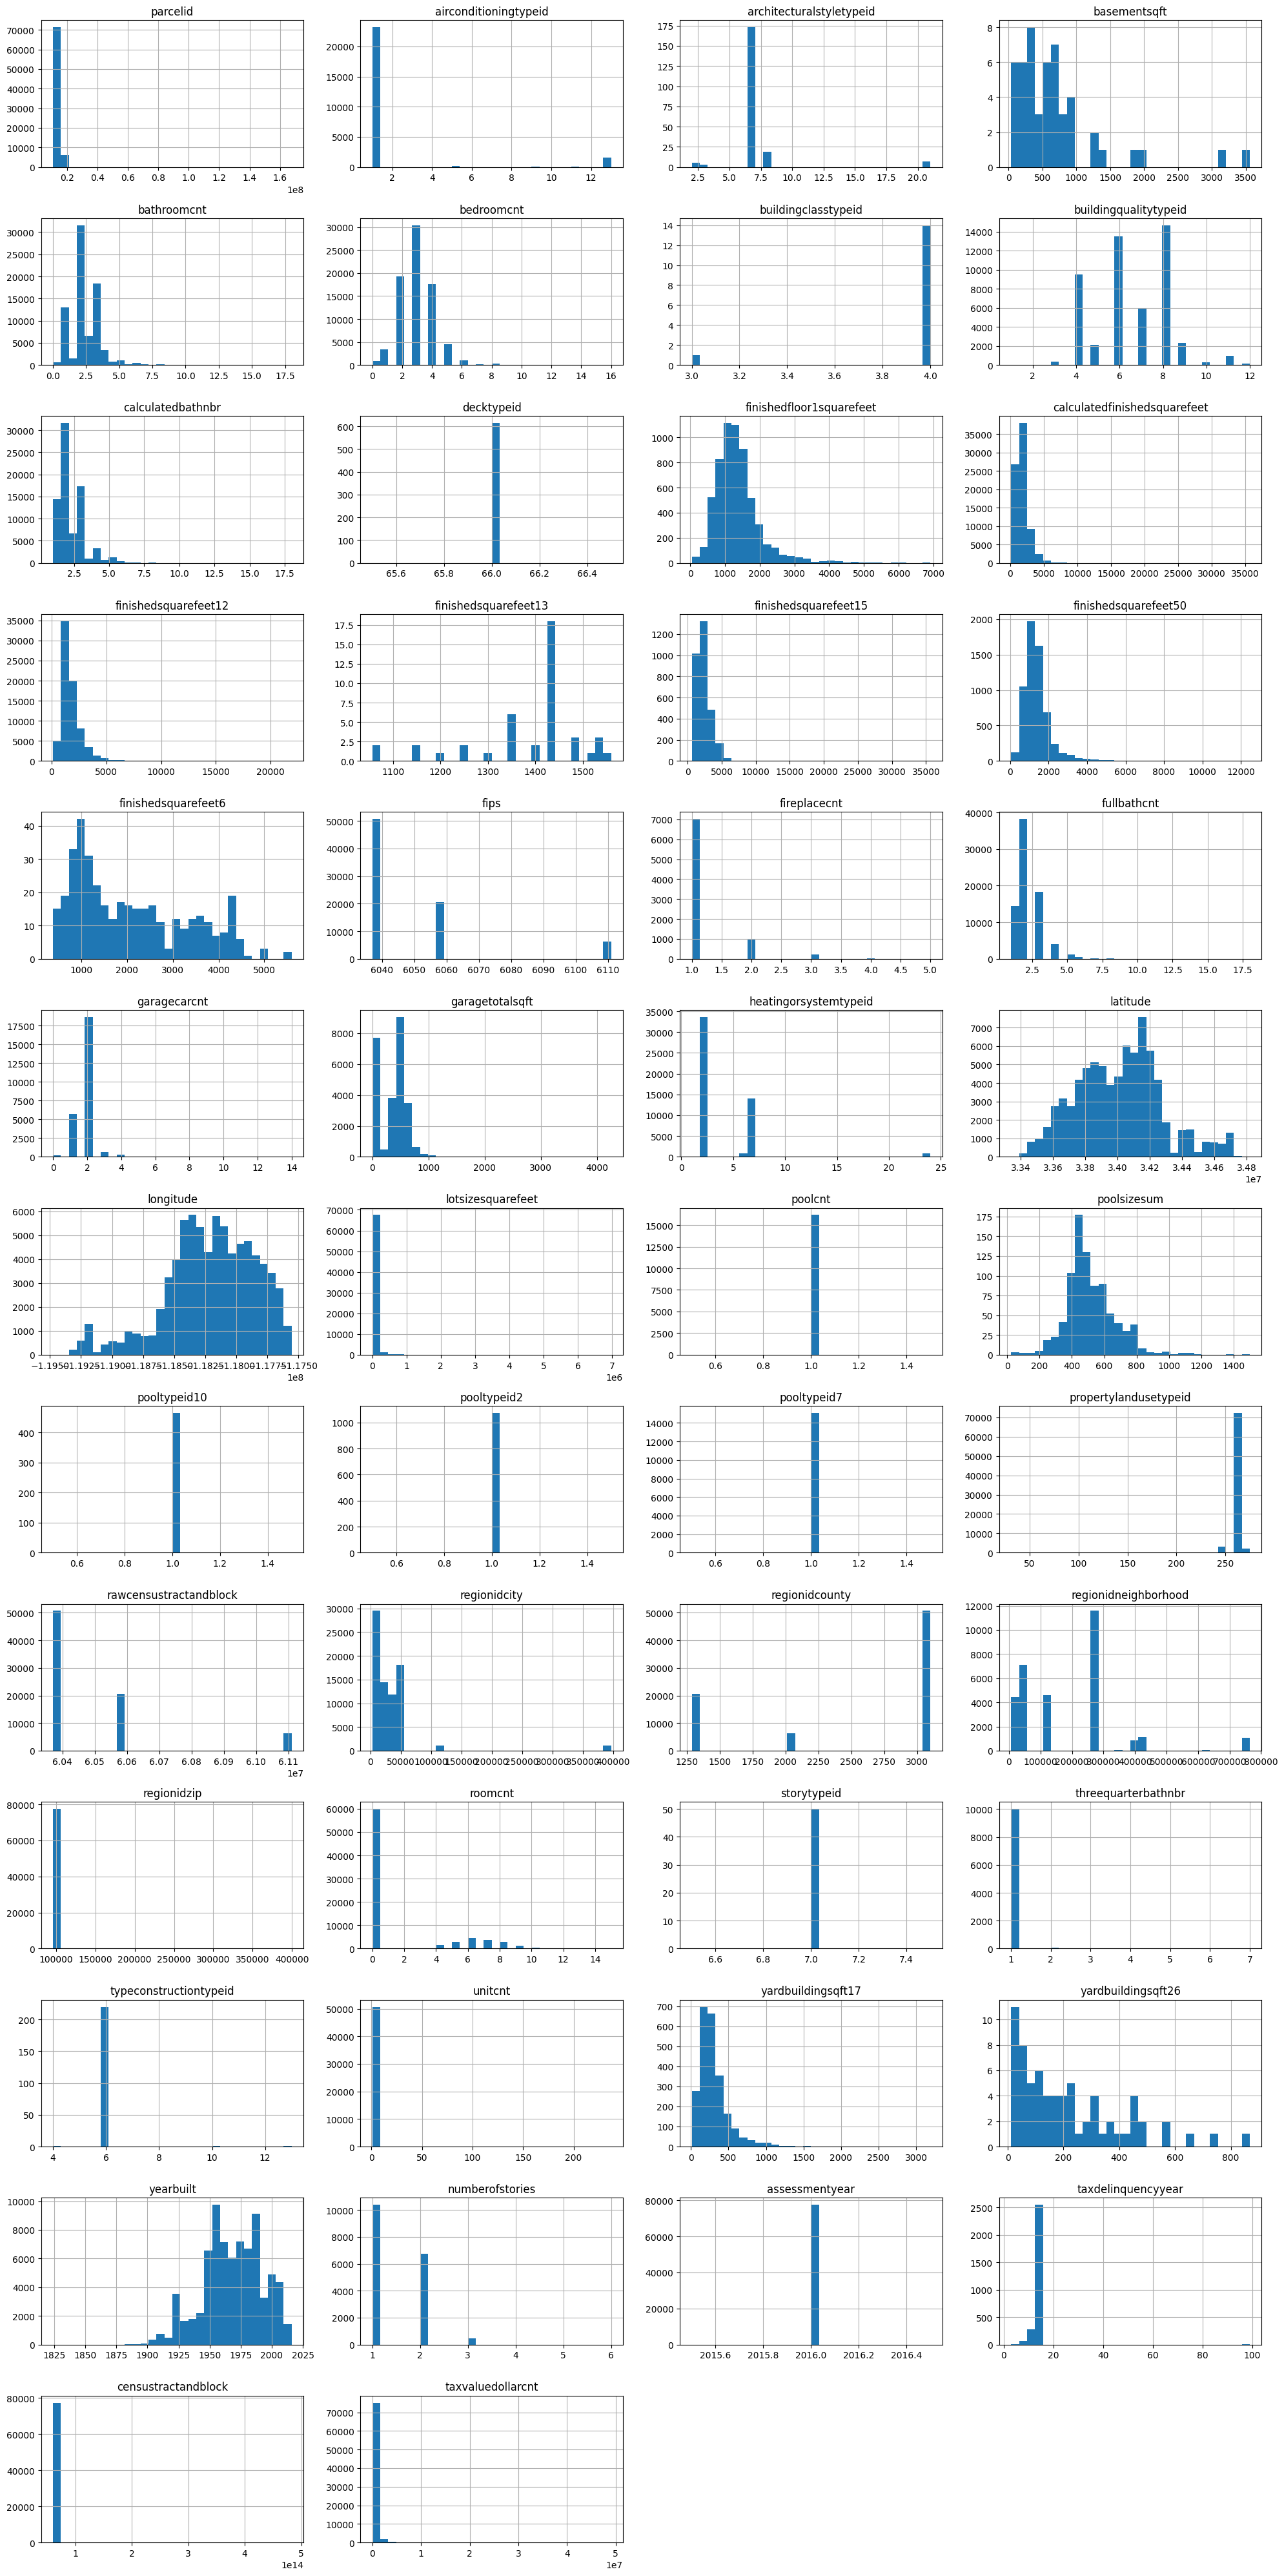

In [7]:
# Generate histograms for all features
df.hist(figsize= (20,40), layout=(-1,4), bins=30)
plt.tight_layout()
plt.show()

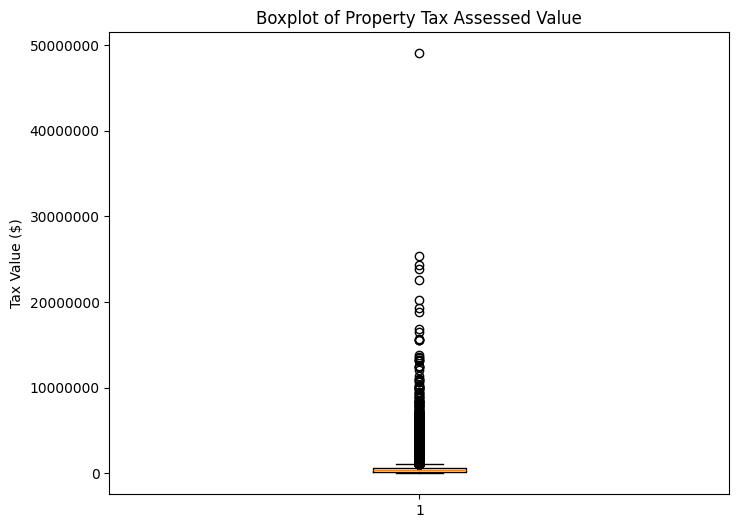

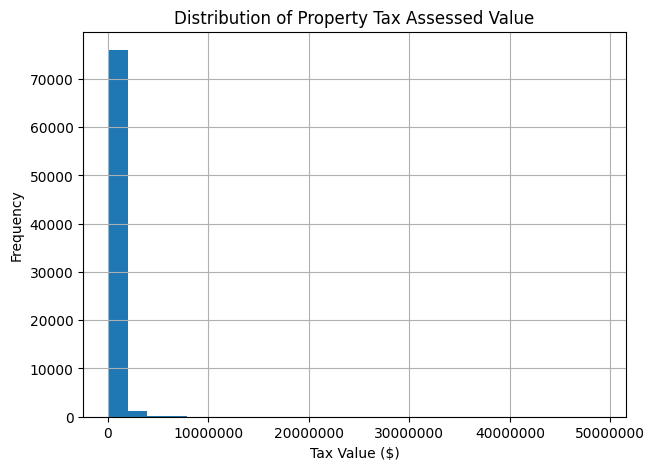

In [8]:
#Generate individual visualizations for the target
plt.figure(figsize=(8,6))
plt.boxplot(df['taxvaluedollarcnt'].dropna(), vert=True)
plt.title('Boxplot of Property Tax Assessed Value')
plt.ylabel('Tax Value ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

plt.figure(figsize=(7,5))
df['taxvaluedollarcnt'].hist(bins=25)
plt.title('Distribution of Property Tax Assessed Value')
plt.xlabel('Tax Value ($)')
plt.ticklabel_format(style='plain', axis='x')
plt.ylabel('Frequency')
plt.show()

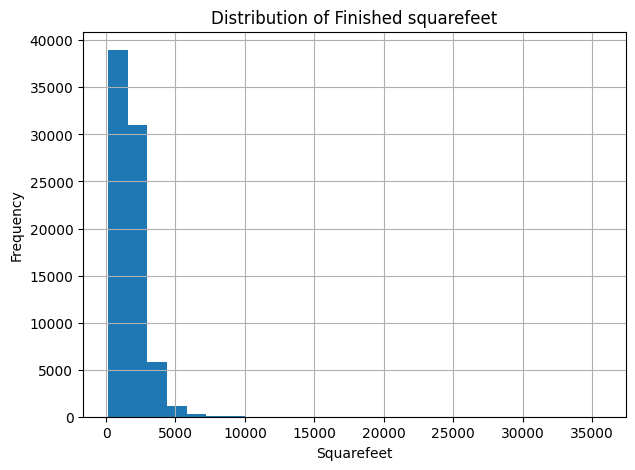

In [9]:
#Generate individual visualizations for feature "calculatedfinishedsquarefeet"
plt.figure(figsize=(7,5))
df['calculatedfinishedsquarefeet'].hist(bins=25)
plt.title('Distribution of Finished squarefeet')
plt.xlabel('Squarefeet')
plt.ylabel('Frequency')
plt.show()

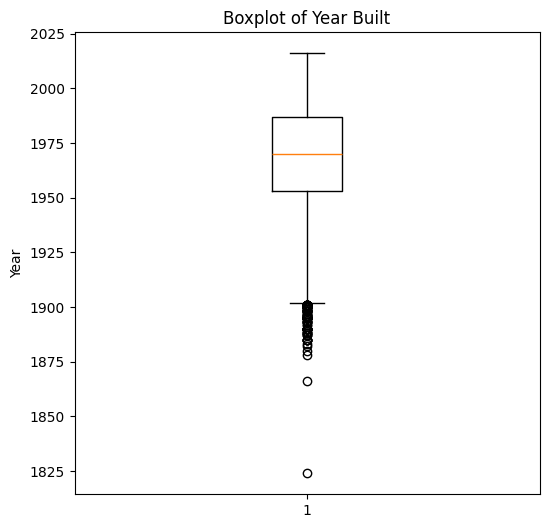

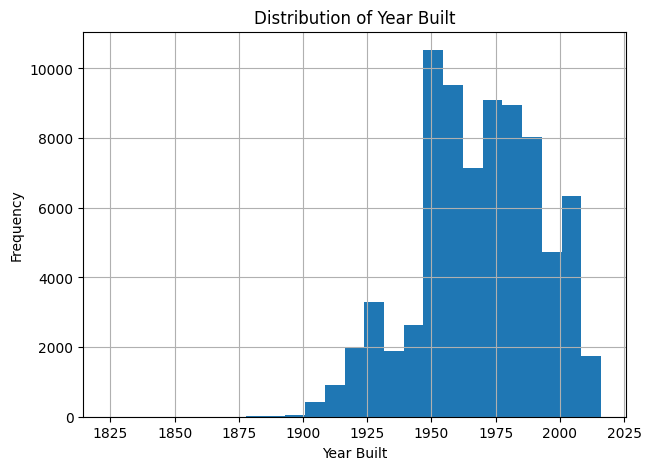

In [10]:
#Generate individual visualizations for feature "yearbuilt"
plt.figure(figsize=(6,6))
plt.boxplot(df['yearbuilt'].dropna(), vert=True)
plt.title('Boxplot of Year Built')
plt.ylabel('Year')

plt.figure(figsize=(7,5))
df['yearbuilt'].hist(bins=25)
plt.title('Distribution of Year Built')
plt.xlabel('Year Built')
plt.ylabel('Frequency')
plt.show()

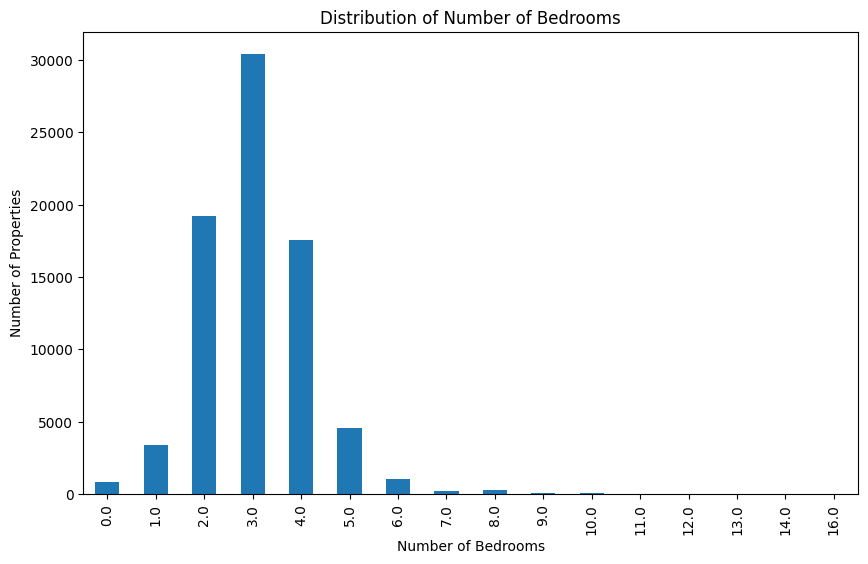

In [11]:
#Generate individual visualizations for feature "bedroomcnt"
plt.figure(figsize=(10, 6))
df['bedroomcnt'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Properties')
plt.show()

#### **2.B Discussion:**

Describe what you learned from your detailed examination of the four features you selected. For each feature, discuss:

- The overall distribution (for example, approximately normal, skewed, or multimodal).
- Any notable characteristics, such as outliers, unusual values, or missing data.
- Why you selected the feature and what you learned about the dataset from examining it.

Conclude by briefly discussing whether any of the features you examined might require additional preprocessing later in the project (such as imputation, transformation, or outlier investigation).

> Replace this text with your answer. Organize your discussion by feature, then conclude with your thoughts about possible future preprocessing.

>**taxvaluedollarcnt:**
The property tax assesed value feature is highly right-skewed, with most properties having low to moderate assessed values and a small number of properties possessing extremely high values. The median lies closer to the lower end of distribution indicating the majority of properties are concentrated within a narrow range of values and a few high-value poperties create a long upper tail. The dataset also contains many extreme outliers including properties with assessed values excedding dollar 10M and some approaching dollar 50M. These may be valid outliers and may represents luxary homes, commercial properties etc. Their presence stretches the overall distribution and can obscure patterns among typical properties. A logarithic transformation can be useful step for modeling.

>**calculatedfinishedsquarefeet:**
The Finished Square Feet feature has a highly right-skewed, unimodal distribution, with most properties ranging from approximately 500 to 3,000 square feet and a small number of exceptionally large properties creating a long upper tail. Several extreme outliers exceed 10,000 square feet, with some reaching nearly 35,000 square feet, likely representing luxury estates, multi-unit properties, or possible data entry errors. Due to the strong positive skew, the mean is expected to be higher than the median. These outliers can influence statistical analyses and model performance, making a logarithmic transformation a useful preprocessing step to reduce skewness. The histogram does not reveal whether missing values exist, so a separate check is required to identify any missing observations.

>**yearbuilt:**
The Year Built feature is slightly left-skewed and unimodal, with most properties constructed between the 1950s and 1990s and a median around 1970. A small number of lower-end outliers represent homes built before 1900, including a few dating back to the early nineteenth century, while the dataset also includes recently built homes up to approximately 2015–2020 without notable upper outliers. These older properties are uncommon and may reflect historically significant or unique homes. The boxplot does not indicate the presence of missing values, so a separate analysis is needed to determine whether any observations are missing.

>**bedroomcnt:** The Number of Bedrooms feature has a unimodal, positively skewed distribution, with most properties containing 2 to 4 bedrooms and a peak at 3 bedrooms. The frequency declines as bedroom counts increase, resulting in a long right tail with a few uncommon properties having 7 to 10 bedrooms. The dataset also includes some properties with 0 bedrooms, which may represent studio units, non-residential properties, or potential data entry issues that should be examined further. Because the variable is discrete, bedroom counts occur only as whole numbers. The histogram does not indicate whether missing values are present, so a separate analysis is needed to identify any missing observations.

**Conclusion**: The exploratory analysis suggests that additional preprocessing is needed before modeling. Property Tax Assessed Value and Finished Square Feet are highly right-skewed with numerous extreme outliers, making a logarithmic transformation (such as log1p) useful for reducing skewness and improving model performance, while the outliers should be examined to confirm whether they are valid observations or data errors. Year Built contains several unusually old properties that may be legitimate historical homes but should be verified, and creating a derived feature such as property age may provide more meaningful information. The Number of Bedrooms feature includes a few properties with exceptionally high bedroom counts and some with zero bedrooms, which may require further investigation or recoding. In addition, all four features should be checked for missing values, as visualizations do not identify missing data. Overall, investigating outliers, reducing skewness, engineering relevant features, and addressing missing values are important preprocessing steps for developing reliable predictive models.


## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [12]:
# Features  to drop to be unsuitable for the regression task
columns_to_drop1 = ['parcelid', 'fips', 'assessmentyear', 'regionidcounty','rawcensustractandblock', 'censustractandblock',
                    'hashottuborspa','pooltypeid7','poolcnt']

#new dataframe
df_reduced1 = df.drop(columns=columns_to_drop1)

# Verify the new shape
print("Original shape:", df.shape)
print("New shape:", df_reduced1.shape)

Original shape: (77613, 55)
New shape: (77613, 46)


#### **3.A Discussion:**

Describe the features you chose to remove, if any, and justify each decision. For each feature, explain:

- Why you believed it was unsuitable for predicting the target.
- Which characteristic led to your decision (for example, an identifier, irrelevant information, or another reason).
- Why your decision was based on the feature's meaning rather than the amount of missing data.

If you chose not to remove any features, explain why.

> Replace this text with your answer.
The variables 'parcelid', 'rawcensustractandblock', 'hashottuborspa','pooltypeid7' and 'censustractandblock' were removed because they serve as unique identifiers and do not provide meaningful information for predictive modeling. The assessmentyear variable was also excluded since it contains only a single unique value, offering no variability or predictive value. In addition, fips and regionidcounty were identified as candidates for removal because they contain only three unique values and represent broad geographic classifications. Their information is largely redundant, as more detailed location features, such as ZIP code, city, latitude, and longitude, are already included in the dataset.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully.

In [13]:
#Step 1 Investigate the missing data
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

high_missing = missing_pct[missing_pct > 80]
print('\n.................................')
print(high_missing)
print('\n.................................')
for col in high_missing.index:
    print(f'{col}: {df[col].notnull().sum()} non-null values')
print('\n.................................')
for col in high_missing.index:
    print(f'{col}: {df[col].nunique()} unique values')
print('\n.................................')
for col in high_missing.index:
    print(f'\n{col}')
    print(df[col].dropna().head())


.................................
buildingclasstypeid         99.980673
finishedsquarefeet13        99.945885
basementsqft                99.935578
storytypeid                 99.935578
yardbuildingsqft26          99.909809
fireplaceflag               99.778388
architecturalstyletypeid    99.733292
typeconstructiontypeid      99.712677
finishedsquarefeet6         99.502661
pooltypeid10                99.400874
decktypeid                  99.208895
poolsizesum                 98.880342
pooltypeid2                 98.616211
hashottuborspa              98.017085
yardbuildingsqft17          96.916754
taxdelinquencyyear          96.263513
taxdelinquencyflag          96.263513
finishedsquarefeet15        96.099880
finishedsquarefeet50        92.221664
finishedfloor1squarefeet    92.221664
fireplacecnt                89.320088
threequarterbathnbr         86.978985
pooltypeid7                 80.571554
dtype: float64

.................................
buildingclasstypeid: 15 non-null values
f

In [14]:
cols_to_drop_missing = [
    'buildingclasstypeid',
    'finishedsquarefeet13',
    'basementsqft',
    'storytypeid',
    'yardbuildingsqft26',
    'fireplaceflag',
    'architecturalstyletypeid',
    'typeconstructiontypeid',
    'finishedsquarefeet6',
    'pooltypeid10',
    'decktypeid',
    'poolsizesum',
    'pooltypeid2',
    'hashottuborspa',
    'taxdelinquencyyear',
    'taxdelinquencyflag',
    'finishedsquarefeet15'
]

df_reduced2 = df.drop(columns=cols_to_drop_missing)
# Verify the new shape
print("Original shape:", df.shape)
print("New shape:", df_reduced2.shape)

Original shape: (77613, 55)
New shape: (77613, 38)


#### **3.B Discussion:**

Describe the criteria you used to decide which features had **too many** missing values to retain.

In particular, explain:

- The threshold you selected for determining when a feature should be removed.
- Why you believe this threshold was appropriate for this dataset.
- Whether you considered the usefulness of the remaining non-null values before deciding to remove a feature, and how this influenced your decision.

To identify features for removal, I calculated the percentage of missing values for each variable and used a 90% missing-value threshold as the main criterion. Features exceeding this threshold were reviewed further based on the number and variability of their remaining observations. Variables such as storytypeid, decktypeid, pooltypeid10, pooltypeid2, hashottuborspa, and taxdelinquencyflag were removed because they had very limited data and provided little predictive value due to low variation. Other features, including buildingclasstypeid, architecturalstyletypeid, basementsqft, and finishedsquarefeet13, were removed because they contained information for too few properties to be useful.However, some highly incomplete variables were retained because their available values still contained meaningful information. For example, finishedfloor1squarefeet, finishedsquarefeet50, fireplacecnt, and threequarterbathnbr had thousands of non-null observations with useful variation. Therefore, feature removal was based not only on missingness but also on the potential predictive value of the remaining data.

### Part 3.C: Remove Problematic Samples

Some samples may not be suitable for model training because they contain insufficient information or cannot be used for supervised learning.

- Remove any sample with a missing target value.
- Decide on a reasonable threshold for the maximum percentage of missing feature values in a sample, justify your choice, and remove samples exceeding that threshold.
- Investigate whether the dataset contains potential outliers, but **do not remove them yet.** Instead, describe how you identified them and explain why removing them may or may not be appropriate. Their effect on model performance will be investigated in Milestone 2.

Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [15]:
# Remove Problematic Samples
df_clean = df.copy()

# 1. Remove data samples with missing target values
df_clean = df_clean[df_clean["taxvaluedollarcnt"].notna()]

# 2. Remove data samples with >90% missing features
row_missing_pct = df_clean.isna().mean(axis=1) * 100
df_clean = df_clean[row_missing_pct <= 90]

print("Remaining rows after cleaning:", df_clean.shape[0])
# Verify the new shape
print("Original shape:", df.shape)
print("New shape:", df_clean.shape)

# 3. Identify outliers
numeric_cols = df_clean.select_dtypes(include=["float64", "int64"]).columns
outlier_summary = {}

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary_df = pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier Count"])
outlier_summary_df.sort_values("Outlier Count", ascending=False).head(10)


Remaining rows after cleaning: 77578
Original shape: (77613, 55)
New shape: (77578, 55)


,Outlier Count
roomcnt,17612
lotsizesquarefeet,11408
garagecarcnt,6881
rawcensustractandblock,6252
fips,6252
censustractandblock,6233
taxvaluedollarcnt,5186
calculatedfinishedsquarefeet,4006
finishedsquarefeet12,3870
propertylandusetypeid,3363


In [16]:
#Final cleaning based on above three steps:
cols_to_drop= [
    'buildingclasstypeid',
    'finishedsquarefeet13',
    'basementsqft',
    'storytypeid',
    'yardbuildingsqft26',
    #'fireplaceflag',
    'architecturalstyletypeid',
    'typeconstructiontypeid',
    'finishedsquarefeet6',
    'pooltypeid10',
    'decktypeid',
    #'poolsizesum',
    'pooltypeid2',
    'hashottuborspa',
    'taxdelinquencyyear',
    #'taxdelinquencyflag',
    'finishedsquarefeet15',
'parcelid', 'fips', 'assessmentyear', 'regionidcounty',#'rawcensustractandblock', 'censustractandblock',
                    #'hashottuborspa'
                    'pooltypeid7','poolcnt']

df_reduced = df.drop(columns=cols_to_drop)
# Remove Problematic Samples
df_clean = df_reduced.copy()

# 1. Remove data samples with missing target values
df_clean = df_clean[df_clean["taxvaluedollarcnt"].notna()]

# 2. Remove data samples with >90% missing features
row_missing_pct = df_clean.isna().mean(axis=1) * 100
df_clean = df_clean[row_missing_pct <= 90]

print("Remaining rows after cleaning:", df_clean.shape[0])
# Verify the new shape
print("Original shape:", df.shape)
print("New shape:", df_clean.shape)

Remaining rows after cleaning: 77578
Original shape: (77613, 55)
New shape: (77578, 35)


#### **3.C Discussion:**

Describe your decisions about which samples were removed and why.

In particular, discuss:

- The criteria you used to identify samples that should be removed (for example, missing target values or excessive missing data).
- If you identified potential outliers, explain how you identified them and why you chose to retain them at this stage.
- The potential advantages and disadvantages of removing outliers, and why you believe this decision should be evaluated experimentally in **Milestone 2**.

> I removed no samples for missing target values, since the target column contains 0% missing data.I initially tested a 40% missing feature threshold, but it eliminated nearly the entire dataset (only 358 rows remained). This revealed that the dataset contains many optional attributes with naturally high missingness. Therefore, I adopted a much more lenient threshold (80-90% missing per row), which removes only the most incomplete samples while preserving the dataset's integrity.

>I identified potential outliers using the IQR method. Several features contain thousands of outliers (e.g., roomcnt: 17,612; lotsizesquarefeet: 11,408; taxvaluedollarcnt: 5,186). Room count value in the outliers output can be a potential outlier. Other outliers correspond to legitimate luxury or unusual properties such as commercial properties, apartment complex etc, so I retained them.
>Removing outliers can reduce model variance, improve performance for typical homes, and help models like linear regression by limiting the influence of extreme values. However, removing them may discard valid luxury properties, lose important information, bias the model toward average homes, and reduce performance on high-priced properties. Since tree-based models are generally robust to outliers, outlier removal is often less necessary for them. Their impact will be evaluated experimentally in Milestone 2.


### Part 3.D: Split the Dataset into Training and Test Sets

Now that the initial data cleaning is complete, split the dataset into training and test sets.

Use:

- test_size=0.20
- random_state=42

The remaining preprocessing steps should be learned **only from the training set** and then applied unchanged to the test set. This prevents information from the test set from influencing the training process ("data leakage").

No discussion necessary.

In [17]:
# Split the Dataset into Training and Test Sets
X = df_clean.drop(columns=["taxvaluedollarcnt"])
y = df_clean["taxvaluedollarcnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (62062, 34)
Test shape: (15516, 34)


### Part 3.E: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Fit your imputation method(s) using only the training data.
- Apply the fitted imputer(s) to both the training and test sets so that no missing values remain.
- Answer the discussion question.


In [18]:
#X.info()
ordinal_cols = ['buildingqualitytypeid']

categorical_cols = [
    'airconditioningtypeid',
    'heatingorsystemtypeid',
    'propertycountylandusecode',
    'propertylandusetypeid',
    'propertyzoningdesc',
    'regionidcity',
    'regionidneighborhood',
    'regionidzip',
    'fireplaceflag',
    'taxdelinquencyflag']

numeric_cols = [col for col in X.columns
                if col not in categorical_cols + ordinal_cols]
print(numeric_cols)

['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet50', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolsizesum', 'rawcensustractandblock', 'roomcnt', 'threequarterbathnbr', 'unitcnt', 'yardbuildingsqft17', 'yearbuilt', 'numberofstories', 'censustractandblock']


In [19]:
# 1. Identify column types
ordinal_cols = ['buildingqualitytypeid']

categorical_cols = [
    'airconditioningtypeid',
    'heatingorsystemtypeid',
    'propertycountylandusecode',
    'propertylandusetypeid',
    'propertyzoningdesc',
    'regionidcity',
    'regionidneighborhood',
    'regionidzip',
    'fireplaceflag',
    'taxdelinquencyflag']

numeric_cols = [col for col in X_train.columns
                if col not in categorical_cols + ordinal_cols]

# 2. Fit imputers on TRAIN only

# Numeric imputer (median)
num_imputer = SimpleImputer(strategy="median")
num_imputer.fit(X_train[numeric_cols])

# Ordinal imputer (median)
ord_imputer = SimpleImputer(strategy="median")
ord_imputer.fit(X_train[ordinal_cols])

# Categorical imputer ("Unknown")
cat_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")
cat_imputer.fit(X_train[categorical_cols])

# 3. Transform TRAIN + TEST
# Numeric
X_train_num = pd.DataFrame(
    num_imputer.transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index)

# Ordinal
X_train_ord = pd.DataFrame(
    ord_imputer.transform(X_train[ordinal_cols]),
    columns=ordinal_cols,
    index=X_train.index)

X_test_ord = pd.DataFrame(
    ord_imputer.transform(X_test[ordinal_cols]),
    columns=ordinal_cols,
    index=X_test.index)

# Categorical
X_train_cat = pd.DataFrame(
    cat_imputer.transform(X_train[categorical_cols]),
    columns=categorical_cols,
    index=X_train.index)

X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test[categorical_cols]),
    columns=categorical_cols,
    index=X_test.index)

# 4. Final combined datasets
X_train_imputed = pd.concat([X_train_num, X_train_ord, X_train_cat], axis=1)
X_test_imputed = pd.concat([X_test_num, X_test_ord, X_test_cat], axis=1)

print("Missing values in TRAIN:", X_train_imputed.isna().sum().sum())
print("Missing values in TEST:", X_test_imputed.isna().sum().sum())


Missing values in TRAIN: 0
Missing values in TEST: 0


#### **3.E Discussion:**

Describe your overall imputation strategy.

In particular, explain:

- Which imputation method(s) you selected.
- Why each method was appropriate for the feature(s) to which it was applied.
- Whether you used different strategies for different types of features (for example, numerical versus categorical, or approximately normal versus skewed numerical features), and why.

> Replace this text with your answer.

I used different imputation strategies for numeric and categorical features based on their characteristics. Numeric features were imputed using the median because the real estate data is highly skewed and contains outliers, making the median a more robust measure of central tendency than the mean. Categorical features were imputed with the constant value "Unknown" because they represent labels rather than quantities, often have very high missingness, and do not have meaningful numeric averages. Using "Unknown" preserves missing information, avoids bias from mode imputation, and allows tree-based models and categorical encoders to treat missing values as a separate category. This approach maintains the statistical integrity of the data, reduces the impact of outliers, and provides clean, meaningful inputs for modeling.

### 3.F: Encode the Categorical Features (if any)

Refer to Appendix 3 for a summary of feature types and appropriate encoding strategies.

- Identify any categorical features that remain after your earlier preprocessing. For each feature, determine whether it is nominal or ordinal, then choose an appropriate encoding method. Use ordinal encoding only for features with a meaningful ordering, and one-hot encoding for nominal features with no natural ordering.

- Fit the encoder(s) using only the training data, then apply the fitted encoder(s) to both the training and test sets. Some teams may have very few categorical features remaining after the earlier cleaning steps.

**Note:** Many categorical features in this dataset are represented by numeric identifier codes (for example, `propertylandusetypeid`). Do not assume that a feature is numerical simply because its data type is int or float. Instead, use the feature descriptions in Appendix 1 and flowchart in Appendix 3 to determine whether the feature represents a numerical measurement or a categorical variable.

In [20]:
# Identify ordinal and nominal categorical features
ordinal_cols = ['buildingqualitytypeid']

nominal_cols = [
    'airconditioningtypeid',
    'heatingorsystemtypeid',
    'propertycountylandusecode',
    'propertylandusetypeid',
    'propertyzoningdesc',
    'regionidcity',
    'regionidneighborhood',
    'regionidzip',
    'fireplaceflag',
    'taxdelinquencyflag']

#Convert to "Unknown", then convert everything to string
X_train_imputed[nominal_cols] = X_train_imputed[nominal_cols].fillna("Unknown").astype(str)
X_test_imputed[nominal_cols] = X_test_imputed[nominal_cols].fillna("Unknown").astype(str)

# Ordinal encoder (ordinal stays numeric)
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
ord_enc.fit(X_train_imputed[ordinal_cols])

# One-hot encoder (nominal now uniform type)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train_imputed[nominal_cols])

# Transform ordinal
X_train_ord = pd.DataFrame(
    ord_enc.transform(X_train_imputed[ordinal_cols]),
    columns=ordinal_cols,
    index=X_train_imputed.index)

X_test_ord = pd.DataFrame(
    ord_enc.transform(X_test_imputed[ordinal_cols]),
    columns=ordinal_cols,
    index=X_test_imputed.index)

# Transform nominal (one-hot)
X_train_ohe = pd.DataFrame(
    ohe.transform(X_train_imputed[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_train_imputed.index)

X_test_ohe = pd.DataFrame(
    ohe.transform(X_test_imputed[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_test_imputed.index)

# Update numeric columns
numeric_cols = [col for col in X_train_imputed.columns
                if col not in ordinal_cols + nominal_cols]

# Combine encoded + numeric features
X_train_final = pd.concat([X_train_imputed[numeric_cols], X_train_ord, X_train_ohe], axis=1)
X_test_final = pd.concat([X_test_imputed[numeric_cols], X_test_ord, X_test_ohe], axis=1)

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)


/tmp/ipykernel_2964/3540597211.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_imputed[nominal_cols] = X_train_imputed[nominal_cols].fillna("Unknown").astype(str)
/tmp/ipykernel_2964/3540597211.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_imputed[nominal_cols] = X_test_imputed[nominal_cols].fillna("Unknown").astype(str)


Final train shape: (62062, 2941)
Final test shape: (15516, 2941)


#### **3.F Discussion:**

Describe the categorical features that remained after your earlier preprocessing.

In particular, discuss:

- Which features you identified as categorical.
- Whether each feature is **nominal** or **ordinal**, and why.
- The encoding method you selected for each feature and why it was appropriate.
- At least one feature that is represented by a numeric identifier rather than text, explaining why it is still categorical and how this influenced your encoding decision.

>
After preprocessing and imputation, I identified eleven categorical features. Based on Appendix1 and Appendix3. These features were identified as categorical because they represent types, labels, IDs, or descriptions, not numeric measurements.
airconditioningtypeid
heatingorsystemtypeid
propertycountylandusecode
propertylandusetypeid
propertyzoningdesc
regionidcity
regionidneighborhood
regionidzip
fireplaceflag
taxdelinquencyflag
buildingqualitytypeid (treated separately as ordinal)

>Ordinal Feature buildingqualitytypeid:
Appendix1 states:“Numeric value indicating the quality of the building (higher values often indicate better quality).”
buildingqualitytypeid feature has a meaningful order, Higher values/better quality.Lower values/poorer quality. Therefore, it is ordinal, even though it is stored as a number.
>All other categorical features(below) are nominal, meaning they have no natural ordering, these are labels, not ranked categories.
airconditioningtypeid : AC type categories
heatingorsystemtypeid : heating system categories
propertycountylandusecode : land use code
propertylandusetypeid : land use type
propertyzoningdesc : zoning description
regionidcity, regionidneighborhood, regionidzip : location identifiers
fireplaceflag : yes/no
taxdelinquencyflag : yes/no

>I applied Ordinal Encoding to the ordinal feature to preserve its ranking, and Onehot Encoding to all nominal features to avoid introducing artificial ordinal relationships.
Ordinal feature (buildingqualitytypeid) Ordinal Encoding: Since the values have a natural ranking (building quality levels), OrdinalEncoder preserves their order. One-hot encoding would ignore this meaningful hierarchy.
Nominal features, One-Hot Encoding: All other categorical features have no inherent order, so one-hot encoding treats each category independently and avoids creating false ordinal relationships. Using handle_unknown='ignore' also prevents errors when unseen categories appear in the test data.

Several categorical features, such as propertylandusetypeid, are represented by numeric codes, but they remain categorical because the numbers function as identifiers rather than measurements. This required treating them as nominal and encoding them with onehot encoding rather than numeric or ordinal methods.


## Part 4: Investigate Feature Relationships [6 pts]

In this part, you will investigate relationships among the features and between the features and the target. The goal is to better understand the dataset and identify opportunities for future feature engineering.

**Important:** At this stage, you should **not** commit to any changes to the dataset based on these analyses. Many preprocessing and feature engineering decisions are model-dependent and will be evaluated experimentally in **Milestone 2**.

### Part 4.A: Correlation and Feature Importance

Investigate relationships among the features and between the features and the target.

In the next cell(s):

- Compute a **correlation matrix** for the numerical features.
- Visualize the results where appropriate (for example, a heatmap and a bar chart).
- Identify features that appear to have particularly strong or weak relationships with the target.
- Identify pairs of features that appear to be highly correlated.
- Do **not** remove or transform any features based on these analyses.

                              bathroomcnt  bedroomcnt  calculatedbathnbr  \
bathroomcnt                      1.000000    0.635265           0.984638   
bedroomcnt                       0.635265    1.000000           0.607747   
calculatedbathnbr                0.984638    0.607747           1.000000   
finishedfloor1squarefeet         0.120514    0.114764           0.124107   
calculatedfinishedsquarefeet     0.766323    0.627380           0.789548   
finishedsquarefeet12             0.740947    0.567791           0.754300   
finishedsquarefeet50             0.118495    0.109510           0.121893   
fireplacecnt                     0.131155    0.096543           0.134720   
fullbathcnt                      0.968640    0.601196           0.984661   
garagecarcnt                     0.220344    0.200130           0.204755   
garagetotalsqft                  0.199459    0.282306           0.194784   
latitude                         0.025357    0.069568           0.020877   
longitude   

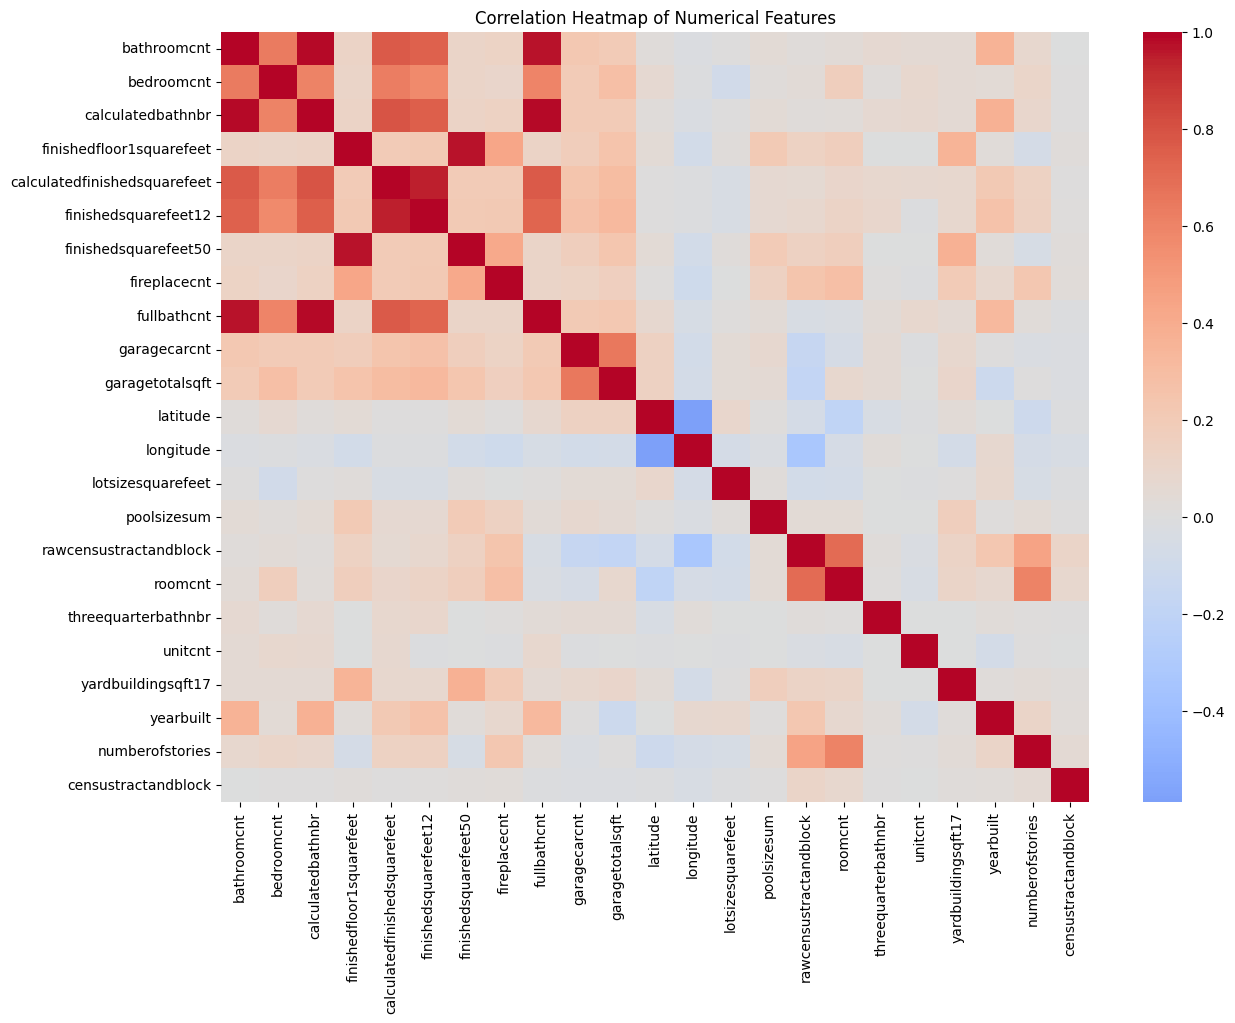

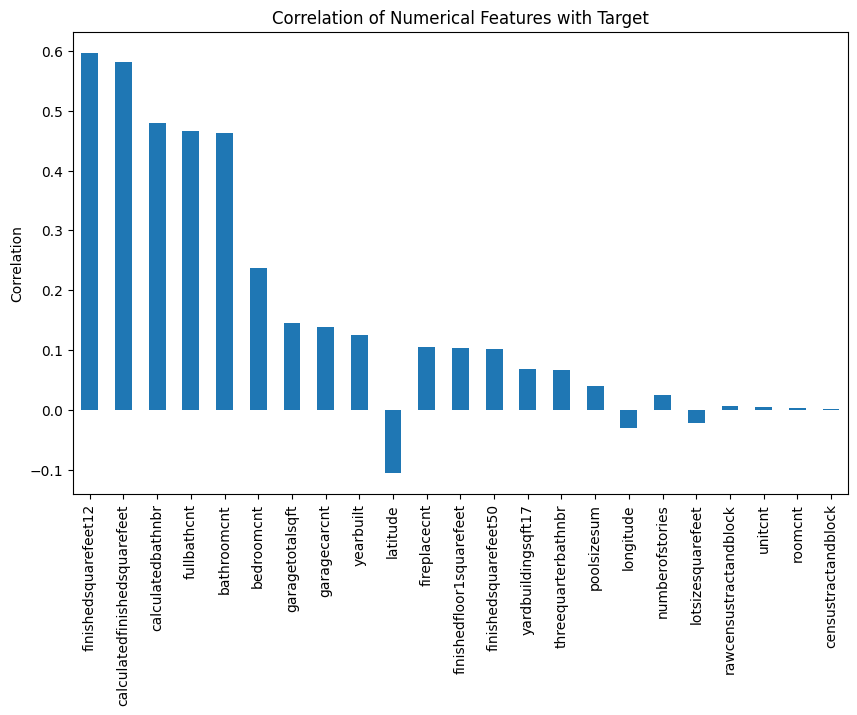

In [21]:
ordinal_cols = ['buildingqualitytypeid']
categorical_cols = [
    'airconditioningtypeid',
    'heatingorsystemtypeid',
    'propertycountylandusecode',
    'propertylandusetypeid',
    'propertyzoningdesc',
    'regionidcity',
    'regionidneighborhood',
    'regionidzip',
    'fireplaceflag',
    'taxdelinquencyflag']
numeric_cols = [col for col in X.columns
                if col not in categorical_cols + ordinal_cols]


#Compute a correlation matrix for the numerical features.
corr_matrix = X_train_imputed[numeric_cols].corr()
print(corr_matrix)
# Visualize the results Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

#Identify features that appear to have particularly strong or weak relationships with the target.
target_corr = X_train_imputed[numeric_cols].corrwith(y_train).sort_values(key=abs, ascending=False)
plt.figure(figsize=(10,6))
target_corr.plot(kind='bar')
plt.title("Correlation of Numerical Features with Target")
plt.ylabel("Correlation")
plt.show()



In [24]:
#Identify pairs of features that appear to be highly correlated
# Find pairs with correlation > 0.6
high_corr_pairs = (
    corr_matrix.where(abs(corr_matrix) > 0.60)
               .stack()
               .reset_index()
)

high_corr_pairs = high_corr_pairs[high_corr_pairs['level_0'] != high_corr_pairs['level_1']]
high_corr_pairs

,level_0,level_1,0
1,bathroomcnt,bedroomcnt,0.635265
2,bathroomcnt,calculatedbathnbr,0.984638
3,bathroomcnt,calculatedfinishedsquarefeet,0.766323
4,bathroomcnt,finishedsquarefeet12,0.740947
5,bathroomcnt,fullbathcnt,0.968640
6,bedroomcnt,bathroomcnt,0.635265
8,bedroomcnt,calculatedbathnbr,0.607747
9,bedroomcnt,calculatedfinishedsquarefeet,0.627380
10,bedroomcnt,fullbathcnt,0.601196
11,calculatedbathnbr,bathroomcnt,0.984638


#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to be the strongest predictors of the target.
- Which pairs of features appeared to be highly correlated.
- Whether the correlation matrix and the F-statistics led you to similar conclusions about the most important features. Explain your reasoning.

>The strongest predictors of tax value were property size, room counts, and year built. Square-footage features such as calculatedfinishedsquarefeet, finishedsquarefeet12, finishedfloor1squarefeet, and finishedsquarefeet50 had the highest F-statistics and strongest correlations, showing that larger homes generally have higher tax assessed values. Bathroom and bedroom variables(bathroomcnt, calculatedbathnbr, fullbathcnt, and bedroomcnt) were also strong predictors because homes with more rooms are typically larger and more valuable. Additionally, yearbuilt showed a moderate positive correlation with tax value, indicating that newer homes tend to be more modern and have higher assesed values.

>The correlation matrix reveals several instances of strong multicollinearity among numerical features. Bathroom-related variables: bathroomcnt, calculatedbathnbr, and fullbathcnt are almost perfectly correlated (correlations around 0.97-0.98), indicating that they capture nearly the same information about the number of bathrooms. Similarly, square-footage variables show very high correlations, with finishedfloor1squarefeet and finishedsquarefeet50 (0.963), and calculatedfinishedsquarefeet and finishedsquarefeet12 (0.946), reflecting overlapping definitions of finished living area. In addition, calculatedfinishedsquarefeet has a strong positive relationship with bathroomcnt(0.766) and fullbathcnt(0.77), suggesting that larger homes generally have more bathrooms, which is an expected real-world pattern

>The correlation matix and F-statistics are consistent in identifying the most important predictors of **taxvaluedollarcnt**. Both analyses showed that square-footage features are the stronest predictors of tax value, with high correlations among themselves and the highest F-statistics. Bathroom-related features are also highly correlated with one another and rank among the top predictors, confirming that bathroom count is an important factor influencing property value. Additionally, **yearbuilt** demonstrates moderate correlations with size and bathroom features while also showing meaningful predictive strength, indicating that newer homes generally tend to have higher tax values.

### Part 4.B: Investigate Feature Relationships

In this part, you will explore relationships between pairs of features to better understand the structure of the dataset and identify opportunities for future feature engineering.

In the next cell(s):

- Select three interesting pairs of features to investigate. Choose pairs that you think may have meaningful relationships based on your earlier exploratory analysis.
- Visualize each pair using an appropriate plot, such as a scatter plot, pairplot, box plot, or another suitable visualization.
- Describe the relationship you observe. Consider whether it appears to be linear, nonlinear, weak, strong, or whether little relationship is evident.
- Do not modify the dataset based on these analyses. Any feature engineering or preprocessing decisions will be evaluated experimentally in Milestone 2.

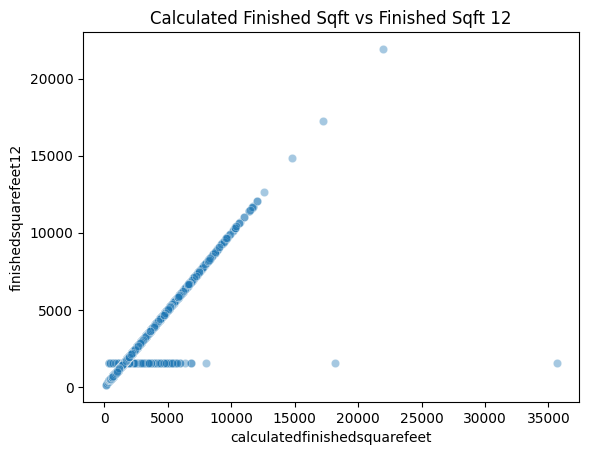

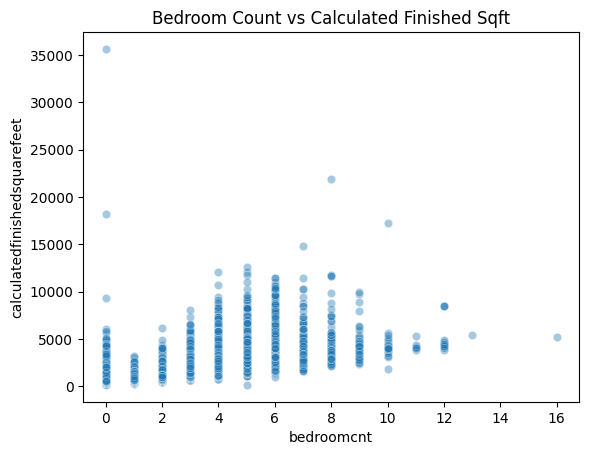

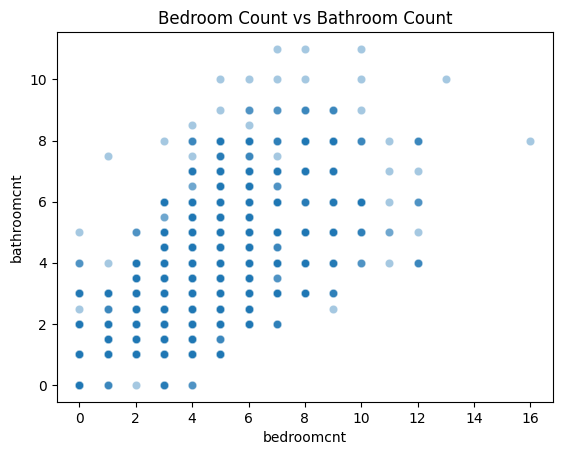

In [27]:
#Select three interesting pairs of features to investigate
#1. calculatedfinishedsquarefeet vs finishedsquarefeet12
sns.scatterplot(
    data=X_train_imputed,
    x='calculatedfinishedsquarefeet',
    y='finishedsquarefeet12',
    alpha=0.4
)
plt.title("Calculated Finished Sqft vs Finished Sqft 12")
plt.show()

#2.bedroomcnt vs calculatedfinishedsquarefeet
sns.scatterplot(
    data=X_train_imputed,
    x='bedroomcnt',
    y='calculatedfinishedsquarefeet',
    alpha=0.4
)
plt.title("Bedroom Count vs Calculated Finished Sqft")
plt.show()

#3.bedroomcnt vs bathroomcnt
sns.scatterplot(
    data=X_train_imputed,
    x='bedroomcnt',
    y='bathroomcnt',
    alpha=0.4
)
plt.title("Bedroom Count vs Bathroom Count")
plt.show()

#### **4.B Discussion:**

Describe what you learned from the three feature relationships you investigated.

For each pair, discuss:

- The overall pattern you observed (for example, linear, nonlinear, weak, or strong).
- What the relationship suggests about the features and their potential usefulness for predicting the target.
- Whether your observations suggest possible feature engineering or preprocessing ideas that could be investigated in **Milestone 2**.

> Pair 1: The relationship between **calculatedfinishedsquarefeet** and **finishedsquarefeet12** appears to be strong, positive, and linear. The two features measure similar aspects of home size, with only minor deviations for a few outliers. This indicates redundancy between the variables and suggests that one could be used as a proxy for the other in modeling. Home size is one of the strongest drivers of assessed tax value. Strong linear relationships between two size-related featires usually indicate that each is individually predictive of **taxvaluedollarcnt**. The analysis suggests several feature engineering directions for Milestone 2. Since the two square-footage variables are highly correlated, one can be removed, combined, or reduced using PCA to reduce multicollinearity. New ratio features, such as square footage per bedroom or bathroom, may improve model performance. Ouliers and inconsistent observations should be reviewed for errors or unusal properties, and the square-footage variables should be compared by missing values, distributions, and outliers to select the most reliable feature.

> Pair 2: The relationship between **bedroomcnt** vs **calculatedfinishedsquarefeet** is positive but nonlinear. As the number of bedrooms increases, the finished square footage generally increases, but not in a perfectly straight line. The relationship is moderately strong, there is clear upward movement, but also considerable spread for each bedroom count. The variability widens for homes with more bedrooms, showing that large homes can vary greatly in size. Both features capture home size and capacity, so they are useful predictors of the target **taxvaluedollarcnt**. The positive trend indicates that larger homes with more bedrooms tend to have higher tax values, though other factors (location, bathroom, year built) also contribute. The spread at higher bedroom counts suggests diminishing returns adding more bedrooms does not always mean proportionally larger square footage. For Milestone 2, feature engineering can include creating ratio features like square feet per bedroom to better capture space efficiently. Outliers in square footage and bedroom counts should be handled through capping or transformations. Nonlinear models and interaction terms between size-related features(such as bedrooms, bathrooms and stories) may also improve prediction performance.

> Pair 3: The relationship between **bedroomcnt** vs **bathroomcnt** is strong and positive, as the number of bedrooms increases, the number of bathrooms also tends to increase. The relationship is roughly linear, though not perfectly straight. There is some spread at each bedroom count, meaning homes with the same number of bedrooms can have different numbers of bathrooms (for example, a 3 bedroom home might have anywhere from 1 to 3 bathrooms). The density of points increases around typical residential configurations (3-5 bedrooms and 2-3 bathrooms). Both features capture home size and quality, so they are usefult predictors of the target **taxvaluedollarcnt**. The positive trend indicates that larger homes with more bedrooms tend to have more bathrooms, which aligns with real-world housing patterns. Because the relationship is strong, these features likely contribute similar information to the model, they may be partially redundant but still valuable together. For Milestone 2, feature engineering can include ratio features such as bathrooms per bedroom to capture home comfort, along with interaction features like total rooms. Outliers in bedroom and bathroom counts should be addressed through capping or transformations and nonlinear models or polynomial features may better capture the realtionship between these variables.

## Part 5: Investigate Potential Feature Engineering [6 pts]

In this part, you will identify potential feature engineering and preprocessing techniques that **may** improve model performance.

The goal is to develop hypotheses based on your exploratory data analysis—not to permanently modify the dataset. In **Milestone 2**, you will evaluate these ideas experimentally and determine whether they actually improve the model.

**Important:** Do **not** permanently transform, remove, or add features in this milestone.

## Part 5.A: Identify Potential Feature Engineering Opportunities

Based on your exploratory analysis, identify **at least three (3)** feature engineering or preprocessing techniques that you believe may improve model performance.

Possible ideas include (but are not limited to):

- Log transformations
- Scaling or normalization
- Removing highly correlated features
- Polynomial features
- Interaction features
- Binning continuous variables
- Outlier removal
- Combining or aggregating existing features

You may investigate these ideas by creating visualizations or performing exploratory analyses, but **do not permanently modify the dataset**.

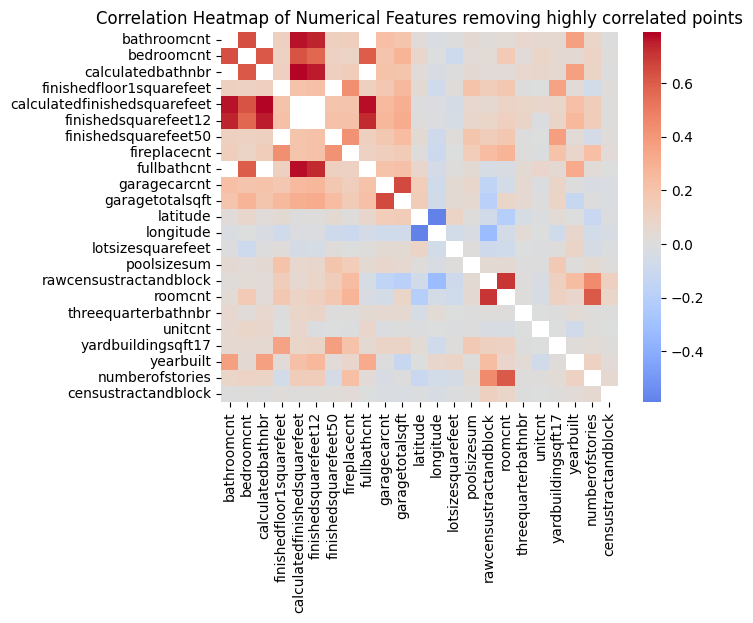

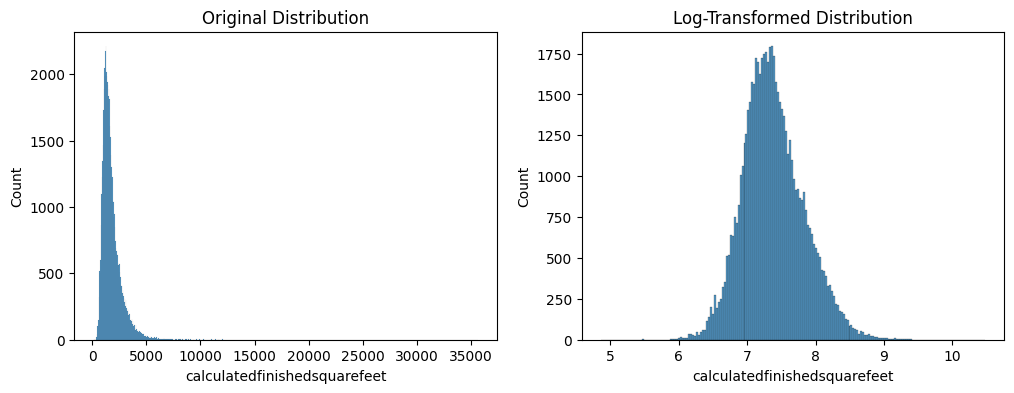

In [34]:
#Removing highly correlated features(example columns were not dropped in the dataset)
#Compute a correlation matrix for the numerical features.
corr_matrix = X_train_imputed[numeric_cols].corr()

# Correlation above 0.9
high_corr = corr_matrix[(corr_matrix)>0.9 & (corr_matrix)<1.0]
high_corr.dropna(how='all', inplace=True)
sns.heatmap(corr_matrix[(corr_matrix<=0.9)], cmap='coolwarm', center=0)
plt.title("Correlation heatmap of numerical features removing highly correlated points")
plt.show()
#sns.heatmap(corr_matrix[(corr_matrix <= 0.9)], cmap='coolwarm', center=0)



#Log transformations
#Before and after Log transformations
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(X_train_imputed['calculatedfinishedsquarefeet'], ax=ax[0])
ax[0].set_title("Original Distribution")
sns.histplot(np.log1p(X_train_imputed['calculatedfinishedsquarefeet']), ax=ax[1])
ax[1].set_title("Log Transformed Distribution")
plt.show()


#Interaction features (for testing code is commented)
#X_ratio = X_train_imputed.copy()
#X_ratio['bathrooms_per_bedroom'] = (
    #X_ratio['bathroomcnt'] / X_ratio['bedroomcnt'].replace(0, np.nan))
#X_ratio['sqft_per_bedroom'] = (
    #X_ratio['calculatedfinishedsquarefeet'] / X_ratio['bedroomcnt'].replace(0, np.nan))

#X_interact = X_train_imputed.copy()
#X_interact['bed_bath_interaction'] = (
    #X_interact['bedroomcnt'] * X_interact['bathroomcnt'])
#X_interact['sqft_year_interaction'] = (
    #X_interact['calculatedfinishedsquarefeet'] * X_interact['yearbuilt'])



In [ ]:
#For testing purpose only
#X_log_scaled = X_train_imputed.copy()
#X_log_scaled['calculatedfinishedsquarefeet'] = np.log1p(X_log_scaled['calculatedfinishedsquarefeet'])

#scaler = StandardScaler()
#X_log_scaled = scaler.fit_transform(X_log_scaled)

#### **5.A Discussion:**

Describe the three feature engineering or preprocessing ideas you identified.

For each one, explain:

- Which feature(s) it would affect.
- Why you believe it may improve model performance.
- How you would determine in **Milestone 2** whether it actually improves the model (for example, by comparing appropriate evaluation metrics on a validation or test set).

>**Removing highly correlated features**

>Several features in the Zillow dataset are highly correlated(coefficien greater than 0.90), indicating that they capture nearly the same information about a property. Examples include: **calculatedfinishedsquarefeet** and **finishedsquarefeet12**
**bathroomcnt**, **calculatedbathnbr** and **fullbathcnt**
**finishedfloor1squarefeet** and **finishedsquarefeet50**

>Highly correlated features are oftern redundant because changes in one variable are almost perfectly reflected in the other. Including all of these variables may introduce multicollinearity, which can negatively affect certain machine learning models, particularly linear regression models. Multicollinearity can inflate the variance of coefficient estimates, making the model parameters unstable and difficult to interpret. Small changes in the training data may lead to large changes in the estimated coefficients, reducing the reliability of the model. Retaining redundant features increases the complexity of the dataset without necessarily adding new information. Extra variables can introduce noise, increase computational cost, and potentially reduce the model's ability to generalize to unseen data. By removing one feature from each highly correlated group, the model becomes simpler and more interpretable while preserving most of underlyting information.

>In Milestone 2, the impact of removing highly correlated features will be evaluated empirically by comparing model performace before and after feature removal. Performance metrics such as validation RMSE, cross-validation scores and test-set performance will be examined. If the simplified model achieves similar or improved predictive performance and demonstartes greater stability across validation folds, then removing the redundant features can be considered beneficial.

>**Log transformations**

>Several continuous variables in the Zillow dataset exhibit strong right-skewed distributions, meaning that most properties have relatively small values while a small number of properties have extremely large values. Examples of such featues include **calculatedfinishedsquarefeet**, **garagetotalsqft** and the target variable **taxvaluedollarcnt**. Although taxvaluedollarcnt is the prediction target and would not be permanently transformed in the dataset, a log transformation may be applied during model training and evaluation.

>Applying a log transformation can improve model performace by reducing skewness and compressing extreme values. This transformation makes the distributions more symmetric and reduces the influence of outliers, which can otherwise dominate the learning process. In many cases, log transformation also make relationships between predictors and the target variable more linear, an important assumption for linear regression models. Furthermore, reducing the range of feature values can improve numerical stabilty and help gradient-based algoriths converge more efficienly during training. After applying log transformation, feature scaling can be beneficail, particularly for models that are sensitive to the magnitude of input variables. Continuous variables such as square footage and garaze size can differ substantially in scale causing features with larger numerical ranges to have a disproportionate influence on the model. Scaling places features on a comparable scale, allowing each variable to contribute more proportionally to the learning process and ofter improving optimization and model stability.

>In milestone 2, the effectiveness of log transformations and scaling will be eavluated empirically by training models with and without these preprocessing techniques. Performance metrics such as RMSE, MAE, R2 and cross-validation scores will be compared. If the transformed and scaled features result in lower prediction error, higher explanatory power or more consistent performance across validation folds, then these preprocessing steps can be considered beneficial for the property tax valuation model.


>**Interaction features**
>The exploratory analysis revealed several strong relationships among the property characteristics, particularly between bedrooms and bathrooms, bedrooms and square footage, and bathroom and square footage. These variables are closely related because larger homes generally have more bedrooms and bathrooms, and the size of a property often influences its layout and functionality. However, these relationships may not be fully captured by the original features alone. Creating interaction and ratio features can provide additional information that better represents the characteristics of a property, and its impact on valuation. For example, a ratio such as bathromms per bedroom can capture aspects of a homes layout quality. Two houses with same number of bedrooms may have different values if one has more bathrooms and more functional floor plan and it will have an impact on the tax dollars. Similarly interaction features that combine square footage with the number of bedrooms or bathrooms can model situations where the effect of one feature depends in the level of another feature.

>These engineered features may also help capture nonlinear relationships and combined effects that are not explicitly represented by the original variables. Property tax values is influenced not only by individual characteristics but also by how those characteristics interact with one another. By incorporating these relationships into the feature set, the model may be able to learn more comples patterns assiciated with property tax values. Tree-based models, such as decision trees and ensemble methods, exploit complex interactions among variables. Linear models may also benefit if the engineered features better appoximate nonlinear relationships present in the data.

>In Milestone 2, the effectiveness of feature engineering will be evaluated empirically by comparing models trained using the original features only, models with ratio features, models with interaction features, and models containing both types of engineered features. Performance will be assessed using RMSE, MAE, R2 and cross-validation scores. If the engineered features reduce prediction error or improve model stability and explanatory power, they can be considered valuable addition to the property tax valuation model.


## Part 5.B: Prioritize Your Ideas

Not all feature engineering ideas are equally promising.

Based on your investigation, select the **two** ideas you believe are most likely to improve model performance.

Briefly explain why you selected these ideas over the others.

No code is required for this section.

#### **5.B Discussion:**

Suppose you had time to evaluate only **two** feature engineering or preprocessing ideas in **Milestone 2**.

For each one, explain:

- Which idea you would prioritize.
- Why you believe it is the most promising.
- What evidence from your exploratory analysis (such as feature distributions, missing values, feature relationships, or other observations) led you to this conclusion.

>Bsed on my exploratory analysis, the tow most promising feature-engeering indeas are 1. removing highly correlated features and 2. applying log transformations to skewed numerical variables.

>**Removing Highly Correlated Features**: The datset contains several highly correlated feature pais(correlation>0.90), such as:
calculatedfinishedsquarefeet and finishedsquarefeet12
bathroomcnt, calculatedbathnbr, and fullbathcnt
finishedfloor1squarefeet and finishedsquarefeet50
These features provide similar information, which can create redundancy and
multicollinearity. Removing duplicate features can improve prediction performance. Evaluation: comparing models with all features vs modells with redundant features removed using RMSE, MAE and cross-validation scores. I selected this idea because the correlation matrix showed clear strong evidence of redundancy in the dataset. Several feature pairs had correlations above 0.90. meaning they were essentially duplicates(for example, multiple square footage measures and multiple bathroom count measures). Keeping both features in a highly correlated pair add noise, increases multicollinearity, and makes linear models less stable. This idea is stronger than others because it directly addressed a confirmed issue in the data rather than a hypithetical one. One explicit proof is that some features overlap heavily, so removing or considering them is a reliable way to simplify the model and improve generalization.

>**Log Transformations for Shewed Features**: Many numercial features especially square-footage and value-related variable, are heavily right-skewed. Applying log transformations can reduce the impact of extreme values, make relationships more linear, improve model stability, reduce the influence of outliers. Evaluation: Compare model using original features vs log-transformed fearures using RMSE, MAE, R2 and cross-validation results. I selected log transformations because the distributions for square-footage variables and other continuous features were strongly right-skewed. This pattern is commin in housing data, and log transforms are a well-established way to stabilize variance, reduce the influence of extreme values, and make relationships more linear. This idea is more promising that others because it directly responds to a visible pattern in the histograms and scatter plots. Unlike polynomial features or binning, which may or may not help log transformations are consistently effective when skew is present.They are also simple, low-risk and easy to evaluate.

#### **5 Discussion:**

Describe in a paragraph why you chose these transformations and what you observed.


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |



## Appendix 3: Flowchart for Identifying Feature Types

The following flowchart can help you identify the statistical type of each feature and determine an appropriate encoding strategy for categorical variables.

![Screenshot 2026-06-28 at 9.25.25 AM.png](attachment:87ba406d-4f6b-4e03-825a-17f4941bb5ac.png)

#### Interesting Question from Piazza:

Hi Professor,

For some Zillow columns, we are not sure whether NaN means true missing data or whether it means the property does not have that feature.

Examples from our dataset:

- poolcnt: 1.0 or NaN
- pooltypeid2, pooltypeid7, pooltypeid10: 1.0 or NaN
- hashottuborspa: True or NaN
- fireplaceflag: True or NaN
- taxdelinquencyflag: Y or NaN
- basementsqft: basement square footage, but mostly NaN
- poolsizesum: total pool square footage, but mostly NaN
- garagecarcnt and garagetotalsqft: garage capacity and garage square footage, but many NaN values
- yardbuildingsqft17 and yardbuildingsqft26: yard building square footage, but mostly NaN

For this type of column, does NaN usually mean that the data is unknown, or does it mean that the property does not have that feature?

For example, for basementsqft, should NaN be treated as missing basement square footage, or should it be treated as 0 because the property likely does not have a basement?

Thank you.

#### My answer:

Great question!   For simplicity, treat all these all as missing. For almost all of these, you could make the argument about missing features,
but I think it would require knowing more about the data collection, or maybe about standard practices in real estate data.

Interesting that HistBoostRegressor in Sklearn bins all the values, does automated imputation, and it can decide for itself whether a missing value
is more "informative" (as trees are constructed) as missing or as "does not apply".

You might investigate this!

#### ChatGPT has an opinion, as always:

One thing I'd emphasize is that NaN is a symbol chosen by whoever created the dataset. It does not have an intrinsic meaning.

Depending on the dataset, NaN might mean:

- the value was never collected,
- the value is unknown,
- the feature does not apply,
- or simply that the data was lost.

Without documentation, we don't actually know.

That's an important lesson for students: missing values are not just a machine learning problem—they're a data understanding problem.